<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
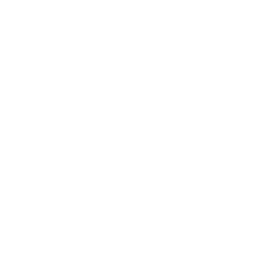
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">임상시험 평가변수를 위한 부트스트랩 신뢰구간</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 제약 / 임상생물통계학 &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 요약

이 예제는 SAS의 행렬 프로그래밍 언어인 **PROC IML**을 사용하여 생존 평가변수에 대한 **비모수적 부트스트랩 신뢰구간**을 계산한다. 평가변수는 소규모 2군 종양학 코호트에서 치료군과 대조군 간의 **무진행생존기간(PFS) 중앙값 비율**이다.

이 IML 프로그램은 피험자 단위 데이터를 행렬로 읽어들이고, 관측된 중앙값 PFS 비율을 계산하며, `CALL RANDGEN`을 사용하여 복원추출로 **부트스트랩 재표본 2,000회**를 추출하고, 각 재표본에서 행렬 연산으로 비율을 재계산한 다음, **편의보정 및 가속(BCa)** 신뢰구간을 도출한다. 중앙값 비율의 부트스트랩 분포는 0을 하한으로 가지며 이산적이고 비대칭적이므로 — 이러한 조건에서는 단순한 정규이론 구간이 신뢰할 수 없기 때문에 — 이 경우 BCa가 적절한 선택이다.

이 분석은 전적으로 IML 내부에서 실행된다: 편의보정 상수 *z*<sub>0</sub>, 일부제거(leave-one-out) 잭나이프에서 구한 가속도 *a&#770;*, 그리고 보정된 백분위수 끝점이 모두 행렬 표현식과 표준정규 함수 `PROBNORM`, 그리고 작은 역정규분포 모듈로부터 계산된다. 아래에 보고된 모든 수치는 IML 출력에서 그대로 가져온 것이다.

## 데이터 소스

| 소스 | 설명 | 관측치 수 |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | 피험자별 PFS 시간, 사건 지표, 치료군 배정, 기저 공변량 | 100 |

이 코호트는 피험자 식별번호의 홀짝성에 따라 군을 배정하여 군당 50명씩 **균형** 잡혀 있으므로, 재표본추출에서도 두 군이 충분히 대표된다.

---


In [1]:
/* --------------------------------------------------------
   가상의 2군 종양학 코호트를 생성한다.
   PFS 시간은 로그정규분포를 따르며, 치료군은 중앙값이 더 길게
   이동되어 있다. 군 배정은 피험자 ID를 기준으로 번갈아
   이루어지므로 코호트는 50/50으로 균형을 이룬다.
   -------------------------------------------------------- */
데이터 work.trial_subjects;
    호출 streaminit(42);
    길이 arm_label $20;
    반복 subject_id = 1 까지 500;
        /* 1 = 치료군, 0 = 대조군 (홀짝으로 균형 배정) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, '치료군', '대조군');
        /* PFS 시간(개월): 치료군이 더 긴 생존기간을 가짐 */
        만약 arm = 1 이면
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        아니면
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        만약 pfs_months < 0.5 이면 pfs_months = 0.5;
        /* 사건 지표: 피험자의 약 75%가 진행 사건을 경험 */
        EVENT = (rand('uniform') > 0.25);
        /* 기저 공변량 */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        만약 AGE < 25 이면 AGE = 25;
        만약 AGE > 85 이면 AGE = 85;
        출력;
    종료;
실행;



NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---


                                                  치료군별 무진행생존기간(PFS) 요약                                                  

                                                  The MEANS Procedure

                                      Analysis Variable : pfs_months PFS (개월)

        치료군                N Obs           Mean         Median        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------
        대조군                   50          10.74           7.20           9.86           1.90          53.70
        치료군                   50          13.94          10.10          11.95           2.70          79.10
        ---------------------------------------------------------------------------------------------------

                                             Analysis Variable : AGE 연령

        치료군                N Obs           Mean         Median        Std Dev        Minimum        Maximum
      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


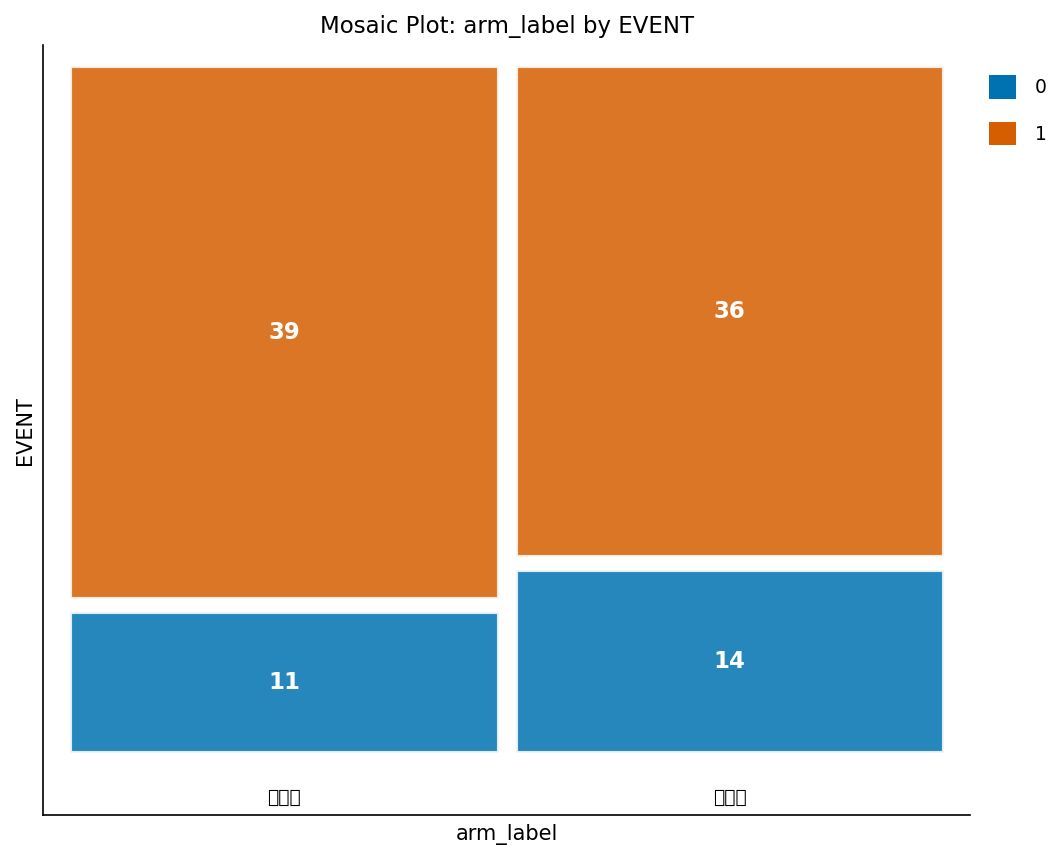

In [2]:
/* --------------------------------------------------------
   치료군별 기저 PFS 요약과 사건 발생률
   -------------------------------------------------------- */
처리 MEANS 데이터=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    분류 arm_label;
    변수 pfs_months AGE;
    라벨 arm_label='치료군' pfs_months='PFS (개월)' AGE='연령';
    제목 '치료군별 무진행생존기간(PFS) 요약';
실행;

처리 FREQ 데이터=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    라벨 arm_label='치료군' EVENT='사건 발생';
    제목 '치료군별 사건 발생 건수';
실행;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: 중앙값 PFS 비율에 대한 비모수적 부트스트랩,
   BCa 신뢰구간 포함.

   단계:
   1. 시험 데이터를 IML 행렬로 읽어들인다
   2. 관측된 중앙값 PFS 비율을 계산한다 (사건 발생 시점)
   3. CALL RANDGEN으로 부트스트랩 재표본 2,000회를 추출한다
   4. 각 재표본에서 비율을 재계산한다
   5. BCa 보정: z0 (편의) + 잭나이프 가속도
   6. 부트스트랩 분포를 SAS 데이터셋에 기록한다
   -------------------------------------------------------- */
처리 IML;

    /* --- 모듈: 군별 중앙값 PFS와 그 비율 --- */
    /* 중앙값은 관측된 사건 발생 시점에 대해서만 계산하며,
       대부분의 피험자가 진행하는 경우의 일반적인
       비모수적 요약이다. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        만약 nrow(trt_pfs) = 0 이면 trt_med = .;
        아니면 trt_med = MEDIAN(trt_pfs);
        만약 nrow(ctl_pfs) = 0 이면 ctl_med = .;
        아니면 ctl_med = MEDIAN(ctl_pfs);
        만약 ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            이면 RATIO = trt_med / ctl_med;
        아니면 RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- 모듈: 표준정규 역누적분포함수 (probit) --- */
    /* 유리함수 근사 (Abramowitz & Stegun 26.2.23);
       PROBNORM과 짝을 이루어 BCa 보정에 필요한
       z0 / z-alpha 끝점을 제공한다. */
    START probit(p);
        만약 p <= 0 이면 RETURN(-1e8);
        만약 p >= 1 이면 RETURN( 1e8);
        만약 p < 0.5 이면 반복; sgn = -1; pp = p;     종료;
        아니면            반복; sgn =  1; pp = 1 - p; 종료;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. 데이터를 행렬로 불러오기 --- */
    USE work.trial_subjects;
        READ ALL 변수 {pfs_months} INTO pfs;
        READ ALL 변수 {arm}        INTO arm;
        READ ALL 변수 {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    인쇄 '피험자가 IML로 읽혔음', n n_trt n_ctl;

    /* --- 2. 전체 표본에 대한 관측 통계량 --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Trt_Median Ctl_Median RATIO};
    인쇄 '군별 관측된 중앙값 PFS (사건 발생 시점)',
          obs[COLNAME=obs_lab 형식=8.3];

    /* --- 3. 부트스트랩 재표본추출 루프 (2,000회) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    호출 randseed(2024);
    반복 b = 1 까지 n_boot;
        호출 randgen(u, 'Uniform');     /* 매 회 새로 추출 */
        idx = ceil(n # u);              /* 1..n 인덱스, 복원추출 */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    종료;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    호출 정렬(bv, 1);

    /* --- 4. (비교용) 단순 백분위수 구간 --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa 보정 --- */
    /* z0: 관측 통계량보다 작은 재표본의 비율로부터의
       편의보정. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a_hat: 일부제거(leave-one-out) 잭나이프로부터의 가속도. */
    jack = j(n, 1, .);
    반복 i = 1 까지 n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    종료;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* 보정된 백분위수 위치. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Valid Prop_Below z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    인쇄 'BCa 보정 진단',
          diag[COLNAME=diag_lab 형식=8.4];

    ci_lab = {Obs_Ratio Pct_Lo Pct_Hi BCa_Lo BCa_Hi};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    인쇄 '중앙값 PFS 비율(치료군/대조군)의 95% 신뢰구간',
          ci_row[COLNAME=ci_lab 형식=8.4];

    /* --- 6. 부트스트랩 분포 저장 --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        변수 {b_id boot obs_col bca_lo_col bca_hi_col};
    추가 변수 {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;


                                                     치료군별 사건 발생 건수                                                      

피험자가 IML로 읽혔음
     100
      50
      50

군별 관측된 중앙값 PFS (사건 발생 시점)
   9.900   7.100   1.394

BCa 보정 진단
2000.0000  0.5340  0.0851 -0.0021

중앙값 PFS 비율(치료군/대조군)의 95% 신뢰구간
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  1.97 seconds
  cpu   1.97 seconds


---


In [4]:
/* --------------------------------------------------------
   그래프를 위해 부트스트랩 분포를 정리한다: 아래 히스토그램에
   사용할 수 있도록 열에 설명적인 이름을 부여한다.
   -------------------------------------------------------- */
데이터 work.bootstrap_results;
    설정 work.bootstrap_results
        (개명=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
실행;



NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                                     치료군별 사건 발생 건수                                                      




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


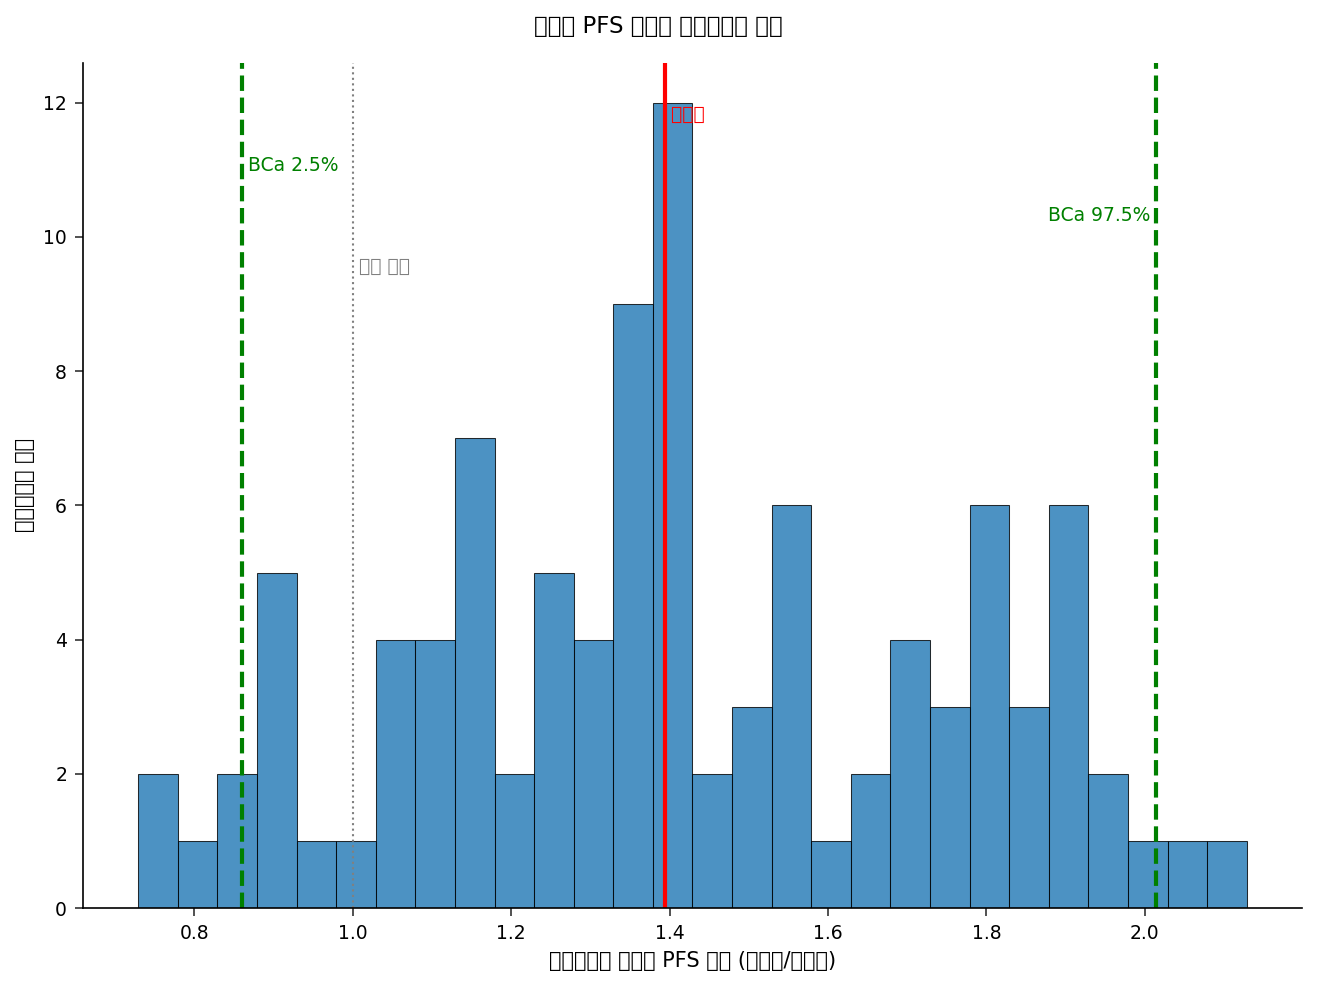

In [5]:
/* --------------------------------------------------------
   중앙값 PFS 비율의 부트스트랩 분포와, 관측 추정값 및
   BCa 구간을 표시한다.
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) 라벨='관측값';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        라벨='BCa 2.5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        라벨='BCa 97.5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        라벨='효과 없음';
    XAXIS 라벨='부트스트랩 중앙값 PFS 비율 (치료군/대조군)';
    YAXIS 라벨='부트스트랩 빈도';
    제목 '중앙값 PFS 비율의 부트스트랩 분포';
실행;


---


### 해석

이 코호트에서 사건 발생 시점에 대한 관측 중앙값 PFS는 치료군 **9.9개월**, 대조군 **7.1개월**로 **비율은 1.394**이다 — 실험군의 중앙값 PFS가 약 39% 더 길다. IML 프로그램은 100명의 피험자를 2,000회 재표본추출했으며, 2,000회 모두에서 정의된 비율이 산출되었다.

비율에 대한 **BCa 95% 신뢰구간은 [0.86, 2.01]**이며, 단순 백분위수 구간인 **[0.82, 1.97]**과 대비된다. 두 구간 모두 **1.0을 포함**하므로, 이 표본 크기 — 군당 약 50명, 게다가 관측된 사건 발생 시점으로 더 축소됨 — 에서는 겉보기 효과가 **통계적으로 결정적이지 않다**. 이것이 이 분석의 정직한 메시지이다: 치료에 유리한 점추정값이지만, 재표본추출의 불확실성이 충분히 커서 치료 효과가 없다는 가능성을 배제할 수 없다.

BCa 진단은 보정이 끝점을 얼마나 이동시켰는지를 정량화한다. 편의항은 작으며(**z<sub>0</sub> = 0.085**: 재표본의 약 53%가 관측 비율보다 낮아, 대칭적인 50%에 근접함), 가속도도 0에 가까워(**a&#770; = -0.002**) 중앙값 PFS 비율이 개별 피험자의 영향을 미미하게만 받는다는 것을 나타낸다. z<sub>0</sub>와 a&#770;가 모두 작으므로, BCa는 백분위수 구간 대비 구간을 약간만 위쪽으로 이동시킨다 — 이는 이 진단값들이 예측하는 만큼의 미미한 보정이다.

더 큰 규모의 시험이라면 이 구간이 더 좁아질 것이다. 군당 50명인 상태에서 부트스트랩은 데이터가 작은 역전에서부터 중앙값 PFS의 2배에 이르기까지 어떤 결과와도 양립할 수 있다는 것을 정확히 보여주며, 이는 이 정도 크기의 PFS 차이를 검출하도록 검정력을 설계한 연구라면 100명을 훨씬 넘는 피험자가 필요한 이유이기도 하다.

---


In [6]:
/* --------------------------------------------------------
   보고서 부록을 위해 부트스트랩 분포를 내보낸다.
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>